In [1]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [2]:
import cooler
import cooltools

In [3]:
# to print which resolutions are stored in the mcool, use list_coolers
cooler.fileops.list_coolers("/usr/users/papantonis1/aman/GEO2457_v2.mcool")

['/resolutions/1000',
 '/resolutions/5000',
 '/resolutions/10000',
 '/resolutions/25000',
 '/resolutions/50000',
 '/resolutions/100000',
 '/resolutions/250000',
 '/resolutions/500000',
 '/resolutions/1000000',
 '/resolutions/2500000']

In [4]:
### to load a cooler with a specific resolution use the following syntax:
clr = cooler.Cooler("/usr/users/papantonis1/aman/GEO2457_v2.mcool::resolutions/1000000")

### to print chromosomes and binsize for this cooler
print(f'chromosomes: {clr.chromnames}, binsize: {clr.binsize}')

### to make a list of chromosome start/ends in bins:
chromstarts = []
for i in clr.chromnames:
    print(f'{i} : {clr.extent(i)}')
    chromstarts.append(clr.extent(i)[0])

chromosomes: ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrM', 'chrX', 'chrY'], binsize: 1000000
chr1 : (0, 249)
chr2 : (249, 492)
chr3 : (492, 691)
chr4 : (691, 882)
chr5 : (882, 1064)
chr6 : (1064, 1235)
chr7 : (1235, 1395)
chr8 : (1395, 1541)
chr9 : (1541, 1680)
chr10 : (1680, 1814)
chr11 : (1814, 1950)
chr12 : (1950, 2084)
chr13 : (2084, 2199)
chr14 : (2199, 2307)
chr15 : (2307, 2409)
chr16 : (2409, 2500)
chr17 : (2500, 2584)
chr18 : (2584, 2665)
chr19 : (2665, 2724)
chr20 : (2724, 2789)
chr21 : (2789, 2836)
chr22 : (2836, 2887)
chrM : (2887, 2888)
chrX : (2888, 3045)
chrY : (3045, 3103)


In [5]:
from matplotlib import colormaps

In [6]:
# count cpus
import os
num_cpus = os.getenv('SLURM_CPUS_PER_TASK')
if not num_cpus:
    num_cpus = os.cpu_count()
num_cpus = int(num_cpus)
print(num_cpus)

48


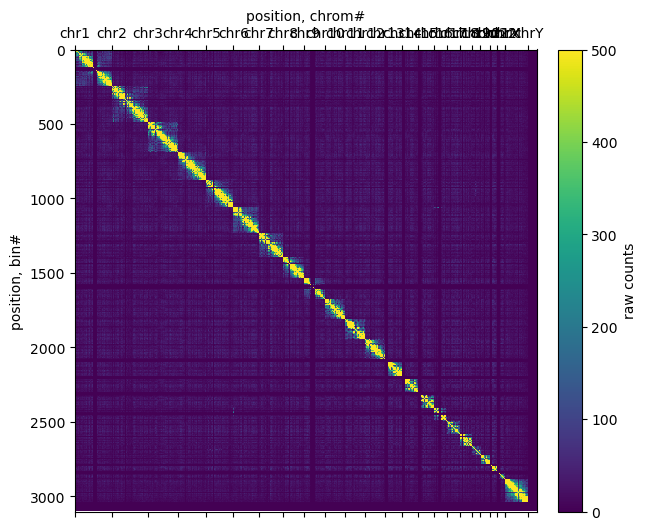

In [7]:
f, ax = plt.subplots(
    figsize=(7,6))
im = ax.matshow((clr.matrix(balance=False)[:]),vmax=500);
plt.colorbar(im ,fraction=0.046, pad=0.04, label='raw counts')
ax.set(xticks=chromstarts, xticklabels=clr.chromnames,
       xlabel='position, chrom#', ylabel='position, bin#')
ax.xaxis.set_label_position('top')

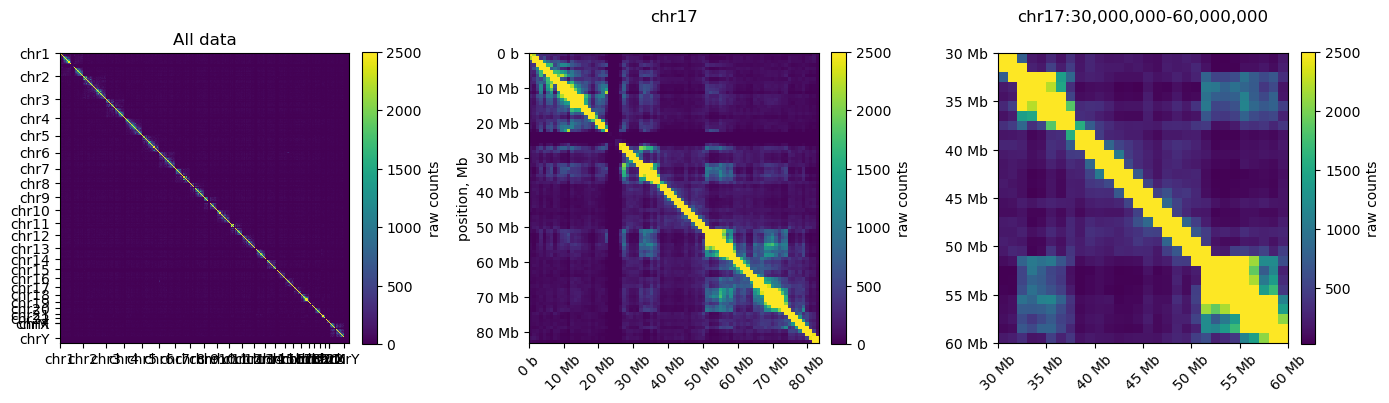

In [8]:
# to plot ticks in terms of megabases we use the EngFormatter
# https://matplotlib.org/gallery/api/engineering_formatter.html
from matplotlib.ticker import EngFormatter
bp_formatter = EngFormatter('b')

def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

f, axs = plt.subplots(
    figsize=(14,4),
    ncols=3)

#Plot 1: Whole-genome view
ax = axs[0]
im = ax.matshow(clr.matrix(balance=False)[:], vmax=2500);
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='raw counts');
ax.set_xticks(chromstarts)
ax.set_xticklabels(clr.chromnames)
ax.set_yticks(chromstarts)
ax.set_yticklabels(clr.chromnames)
ax.xaxis.tick_bottom()
ax.set_title('All data')

#Plot 2: Single chromosome (chr17)
ax = axs[1]
im = ax.matshow(
    clr.matrix(balance=False).fetch('chr17'),
    vmax=2500,
    extent=(0,clr.chromsizes['chr17'], clr.chromsizes['chr17'], 0)
);
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='raw counts');
ax.set_title('chr17', y=1.08)
ax.set_ylabel('position, Mb')
format_ticks(ax)

#Plot 3: Zoom into a region of chr17
ax = axs[2]
start, end = 30_000_000, 60_000_000
region = ('chr17', start, end)
im = ax.matshow(
    clr.matrix(balance=False).fetch(region),
    vmax=2500,
    extent=(start, end, end, start)
);
ax.set_title(f'chr17:{start:,}-{end:,}', y=1.08)
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='raw counts');
format_ticks(ax)
plt.tight_layout()

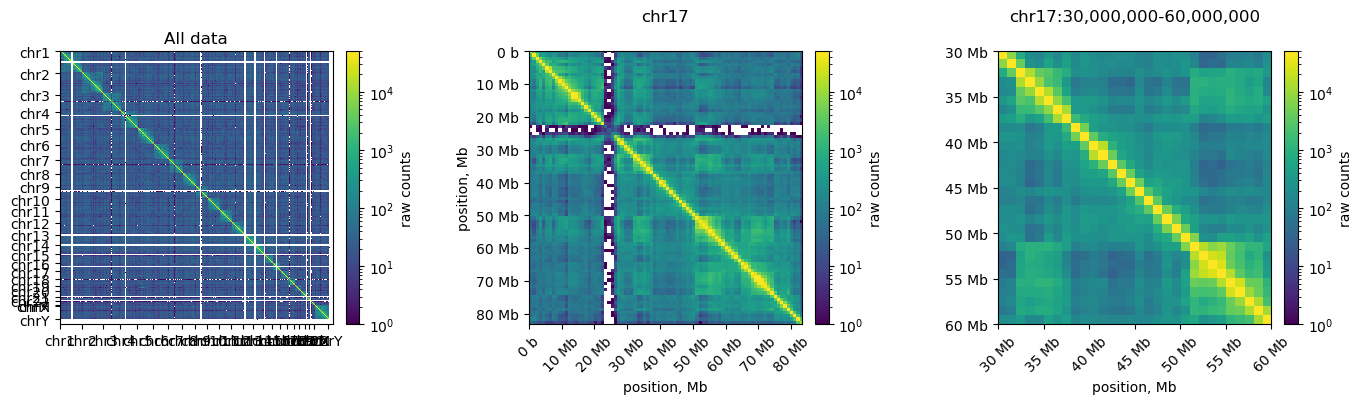

In [9]:
# plot heatmaps at megabase resolution with 3 levels of zoom in log-scale with a consistent colormap#
from matplotlib.colors import LogNorm

f, axs = plt.subplots(
    figsize=(14,4),
    ncols=3)
bp_formatter = EngFormatter('b')
norm = LogNorm(vmax=50_000)

ax = axs[0]
im = ax.matshow(
    clr.matrix(balance=False)[:],
    norm=norm,
)
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='raw counts');
ax.set_xticks(chromstarts)
ax.set_xticklabels(clr.chromnames)
ax.set_yticks(chromstarts)
ax.set_yticklabels(clr.chromnames)
ax.xaxis.tick_bottom()
ax.set_title('All data')

ax = axs[1]
im = ax.matshow(
    clr.matrix(balance=False).fetch('chr17'),
    norm=norm,
    extent=(0,clr.chromsizes['chr17'], clr.chromsizes['chr17'], 0)
);
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='raw counts');
ax.set_title('chr17', y=1.08)
ax.set(ylabel='position, Mb', xlabel='position, Mb')
format_ticks(ax)

ax = axs[2]
start, end = 30_000_000, 60_000_000
region = ('chr17', start, end)
im = ax.matshow(
    clr.matrix(balance=False).fetch(region),
    norm=norm,
    extent=(start, end, end, start)
);
ax.set_title(f'chr17:{start:,}-{end:,}', y=1.08)
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='raw counts');
ax.set(xlabel='position, Mb')
format_ticks(ax)
plt.tight_layout()

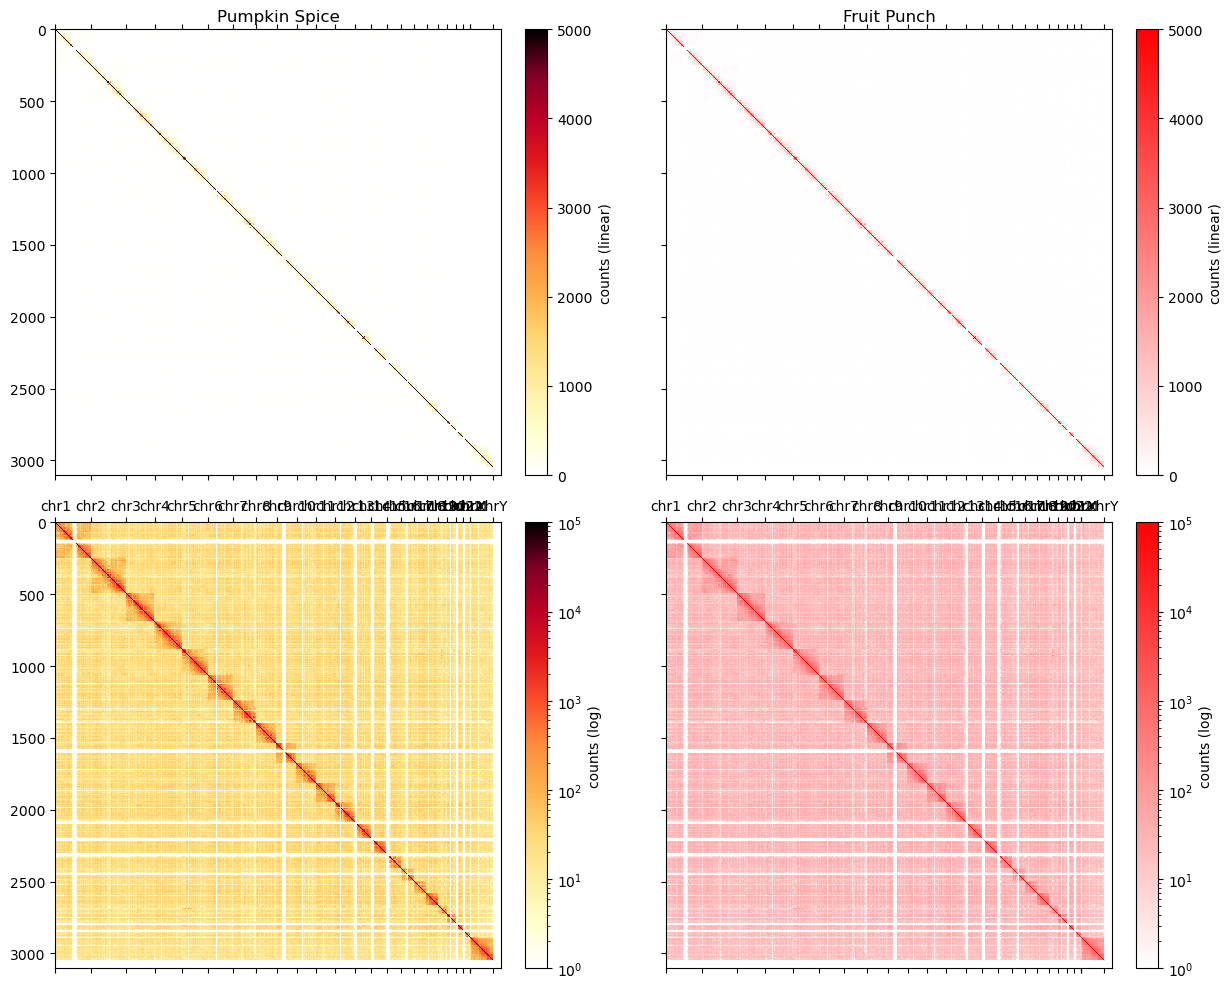

In [10]:
### plot the corrected data in fall heatmap and compare to the white-red colormap ###
### thanks for the alternative collormap naming to https://twitter.com/HiC_memes/status/1286326919122825221/photo/1###
import cooltools.lib.plotting

vmax = 5000
norm = LogNorm(vmin=1, vmax=100_000)
fruitpunch = sns.blend_palette(['white', 'red'], as_cmap=True)

f, axs = plt.subplots(
    figsize=(13, 10),
    nrows=2,
    ncols=2,
    sharex=True, sharey=True)

ax = axs[0, 0]
ax.set_title('Pumpkin Spice')
im = ax.matshow(clr.matrix(balance=False)[:], vmax=vmax, cmap='fall');
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='counts (linear)');
plt.xticks(chromstarts,clr.chromnames);

ax = axs[0, 1]
ax.set_title('Fruit Punch')
im3 = ax.matshow(clr.matrix(balance=False)[:], vmax=vmax, cmap=fruitpunch);
plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04, label='counts (linear)');
plt.xticks(chromstarts,clr.chromnames);

ax = axs[1, 0]
im = ax.matshow(clr.matrix(balance=False)[:], norm=norm, cmap='fall');
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='counts (log)');
plt.xticks(chromstarts,clr.chromnames);

ax = axs[1, 1]
im3 = ax.matshow(clr.matrix(balance=False)[:], norm=norm, cmap=fruitpunch);
plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04, label='counts (log)');
plt.xticks(chromstarts,clr.chromnames);

plt.tight_layout()

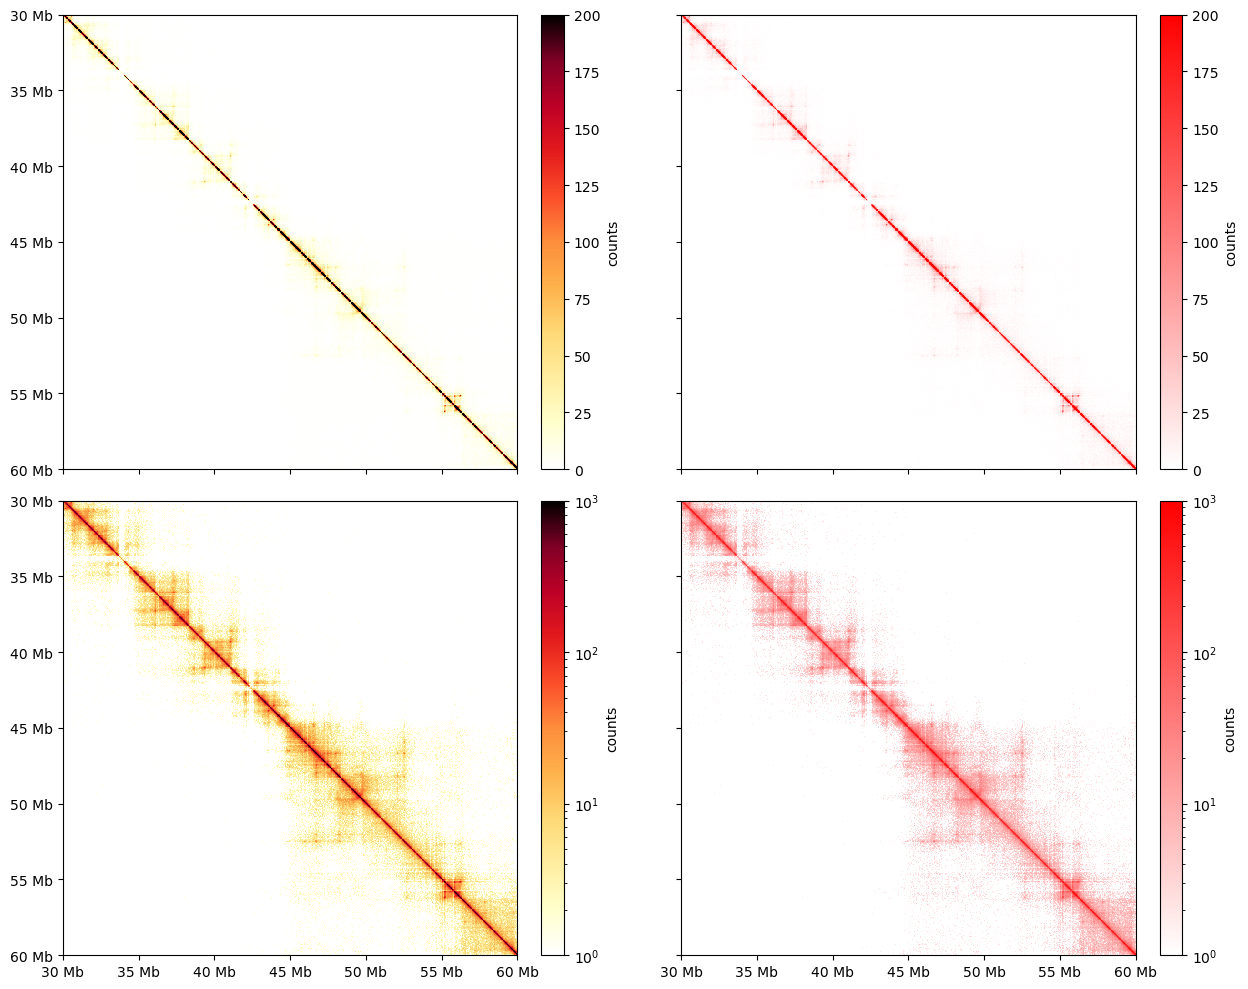

In [15]:
### plot the corrected data in fall heatmap ###
import cooltools.lib.plotting
clr_10kb = cooler.Cooler("/usr/users/papantonis1/aman/GEO2457_v2.mcool::resolutions/10000")

region = 'chr17:30,000,000-35,000,000'
extents = (start, end, end, start)
norm = LogNorm(vmin=1, vmax=1000)

f, axs = plt.subplots(
    figsize=(13, 10),
    nrows=2,
    ncols=2,
    sharex=True,
    sharey=True
)

ax = axs[0, 0]
im = ax.matshow(
    clr_10kb.matrix(balance=False).fetch(region),
    cmap='fall',
    vmax=200,
    extent=extents
);
plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='counts');

ax = axs[0, 1]
im2 = ax.matshow(
    clr_10kb.matrix(balance=False).fetch(region),
    cmap=fruitpunch,
    vmax=200,
    extent=extents
);
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04, label='counts');

ax = axs[1, 0]
im = ax.matshow(
    clr_10kb.matrix(balance=False).fetch(region),
    cmap='fall',
    norm=norm,
    extent=extents
);
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='counts');

ax = axs[1, 1]
im2 = ax.matshow(
    clr_10kb.matrix(balance=False).fetch(region),
    cmap=fruitpunch,
    norm=norm,
    extent=extents
);
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04, label='counts');

for ax in axs.ravel():
    format_ticks(ax, rotate=False)
plt.tight_layout()

## Balancing

In [17]:
clr.bins()[:6]

,chrom,start,end,KR,SCALE,VC,VC_SQRT,weight
0,chr1,0,1000000,0.210109,0.211023,0.510063,0.241782,NaN
1,chr1,1000000,2000000,0.575263,0.577765,2.961996,0.582646,NaN
2,chr1,2000000,3000000,0.589780,0.592344,3.238691,0.609253,NaN
3,chr1,3000000,4000000,0.661227,0.664101,3.937721,0.671793,NaN
4,chr1,4000000,5000000,0.578647,0.581161,3.176345,0.603360,NaN
5,chr1,5000000,6000000,0.661787,0.664663,3.958813,0.673589,NaN


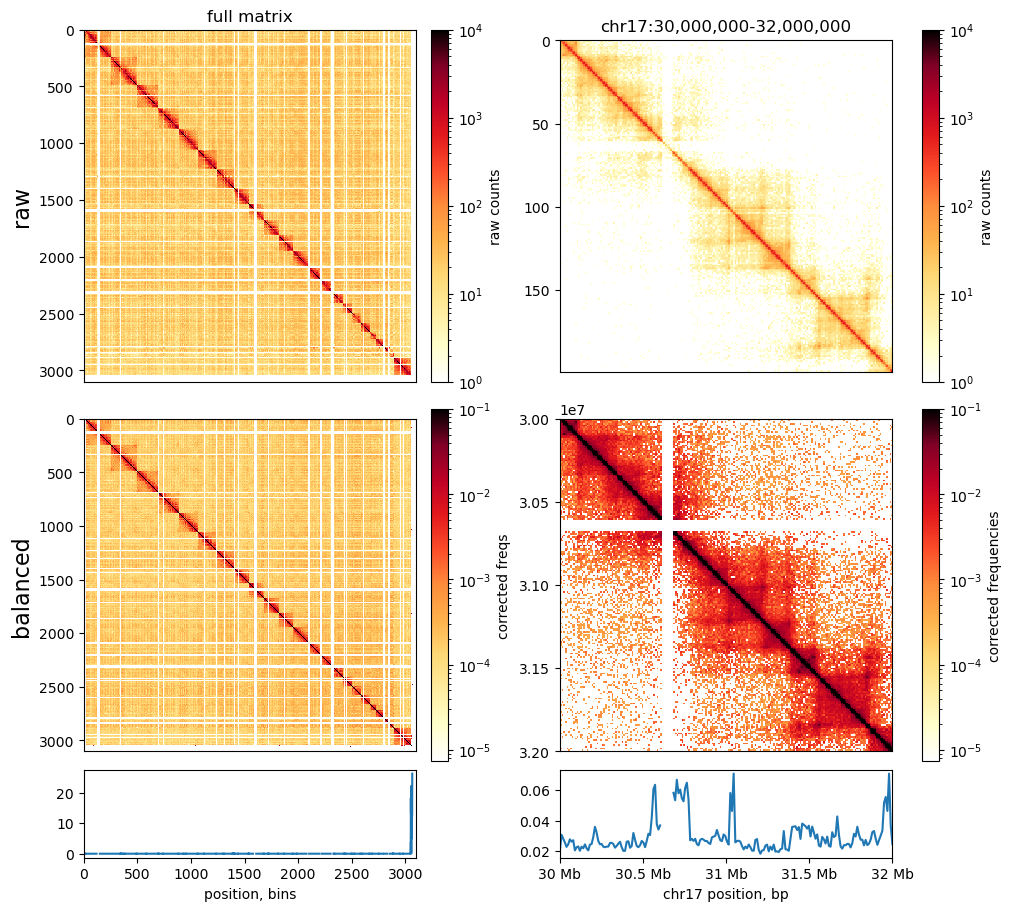

In [18]:
### plot the raw and corrected data in logscale ###
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt_width=4
f, axs = plt.subplots(
    figsize=( plt_width+plt_width+2, plt_width+plt_width+1),
    ncols=4,
    nrows=3,
    gridspec_kw={'height_ratios':[4,4,1],"wspace":0.01,'width_ratios':[1,.05,1,.05]},
    constrained_layout=True
)

norm = LogNorm(vmax=0.1)
norm_raw = LogNorm(vmin=1, vmax=10_000)

ax = axs[0,0]
im = ax.matshow(
    clr.matrix(balance=False)[:],
    norm=norm_raw,
    cmap='fall',
    aspect='auto'
);
ax.xaxis.set_visible(False)
ax.set_title('full matrix')
ax.set_ylabel('raw', fontsize=16)

cax = axs[0,1]
plt.colorbar(im, cax=cax, label='raw counts')

ax = axs[1,0]
im = ax.matshow(
    clr.matrix()[:], # clr.matrix() is same as clr.matrix(balance=True)
    norm=norm,
    cmap='fall',
);
ax.xaxis.set_visible(False)
ax.set_ylabel('balanced', fontsize=16)

cax = axs[1,1]
plt.colorbar(im, cax=cax, label='corrected freqs')

ax1 = axs[2,0]
weights = clr.bins()[:]['weight'].values
ax1.plot(weights)
ax1.set_xlim([0, len(clr.bins()[:])])
ax1.set_xlabel('position, bins')

ax1 = axs[2,1]
ax1.set_visible(False)



start = 30_000_000
end = 32_000_000
region = ('chr17', start, end)

ax = axs[0,2]
im = ax.matshow(
        clr_10kb.matrix(balance=False).fetch(region),
    norm=norm_raw,
    cmap='fall'
);
ax.set_title(f'chr17:{start:,}-{end:,}')
ax.xaxis.set_visible(False)

cax = axs[0,3]
plt.colorbar(im, cax=cax, label='raw counts');

ax = axs[1,2]
im = ax.matshow(
    clr_10kb.matrix().fetch(region),
    norm=norm,
    cmap='fall',
    extent=(start, end, end, start)
);
ax.xaxis.set_visible(False)

cax = axs[1,3]
plt.colorbar(im, cax=cax, label='corrected frequencies');

ax1 = axs[2,2]
weights = clr_10kb.bins().fetch(region)['weight'].values
ax1.plot(
    np.linspace(start, end, len(weights)),
    weights
)
format_ticks(ax1, y=False, rotate=False)
ax1.set_xlim(start, end);
ax1.set_xlabel('chr17 position, bp')

ax1 = axs[2,3]
ax1.set_visible(False)

In [24]:
# Code to check how many bins in the .cool file are balanced:
import numpy as np
weights = clr.bins()[:]['weight'].values
print(f"Valid weights: {np.sum(~np.isnan(weights))}/{len(weights)}")

# metadata on cool file
print(clr.info) # no. of bins and bin size especially 

Valid weights: 2769/3103
{'bin-size': 1000000, 'bin-type': 'fixed', 'creation-date': '2025-04-15T16:24:36.932144', 'format': 'HDF5::Cooler', 'format-url': 'https://github.com/4dn-dcic/hic2cool', 'format-version': 3, 'generated-by': 'hic2cool-0.6.0', 'genome-assembly': 'chr_size.tsv', 'hicFileScalingFactor': 1.0, 'nbins': 3103, 'nchroms': 25, 'nnz': 4150997, 'nviIndex': '0000000000000000', 'nviLength': '0000000000000000', 'software': 'Juicer Tools Version 1.22.01', 'storage-mode': 'symmetric-upper'}


/tmp/ipykernel_1781401/2472743492.py:30: RuntimeWarning: invalid value encountered in divide
  ax2.plot( cis_coverage/ tot_coverage)


Text(0, 0.5, 'coverage ratio')

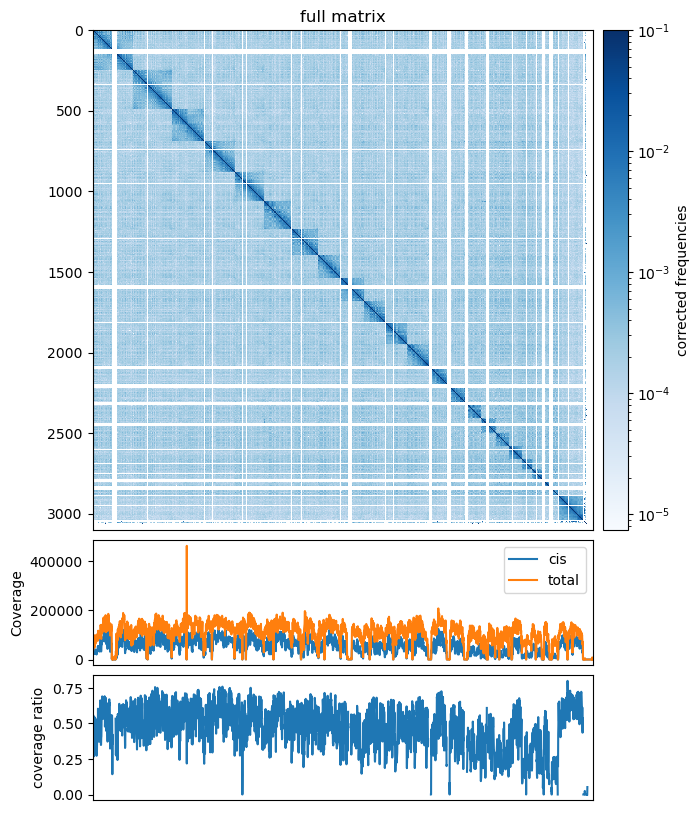

In [27]:
cis_coverage, tot_coverage = cooltools.coverage(clr)

f, ax = plt.subplots(
    figsize=(15, 10),
)

norm = LogNorm(vmax=0.1)

im = ax.matshow(
    clr.matrix()[:],
    norm=norm,
    cmap='Blues'
);
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax, label='corrected frequencies');
ax.set_title('full matrix')
ax.xaxis.set_visible(False)

ax1 = divider.append_axes("bottom", size="25%", pad=0.1, sharex=ax)
weights = clr.bins()[:]['weight'].values
ax1.plot( cis_coverage, label='cis')
ax1.plot( tot_coverage, label='total')
ax1.set_xlim([0, len(clr.bins()[:])])
ax1.set_ylabel('Coverage')
ax1.legend()
ax1.set_xticks([])

ax2 = divider.append_axes("bottom", size="25%", pad=0.1, sharex=ax)
ax2.plot( cis_coverage/ tot_coverage)
ax2.set_xlim([0, len(clr.bins()[:])])
ax2.set_ylabel('coverage ratio')